In [1]:
from pathlib import Path
import pandas as pd

In [2]:
DATA_DIR=Path('final_data')
classes=["no_dr","mild","moderate","severe","proliferative_dr"]

for cls in classes:
    file=list((DATA_DIR/cls).glob("*"))

    print(cls,len(file))

no_dr 1935
mild 393
moderate 1156
severe 278
proliferative_dr 360


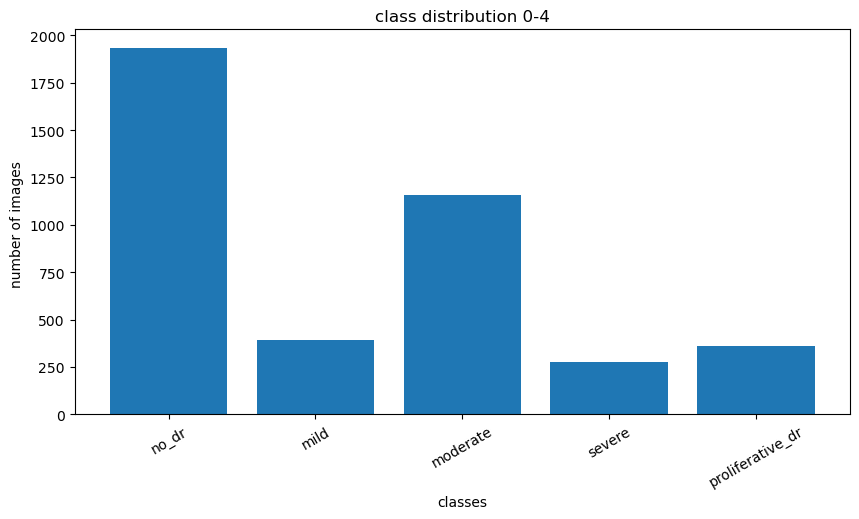

In [3]:
import matplotlib.pyplot as plt 
counts=[]


for cls in classes:
    count=len(list((DATA_DIR/cls).glob("*")))
    counts.append(count)

plt.figure(figsize=(10,5))
plt.bar(classes,counts)
plt.xticks(rotation=30)
plt.ylabel("number of images ")
plt.xlabel("classes")
plt.title("class distribution 0-4")
plt.show()

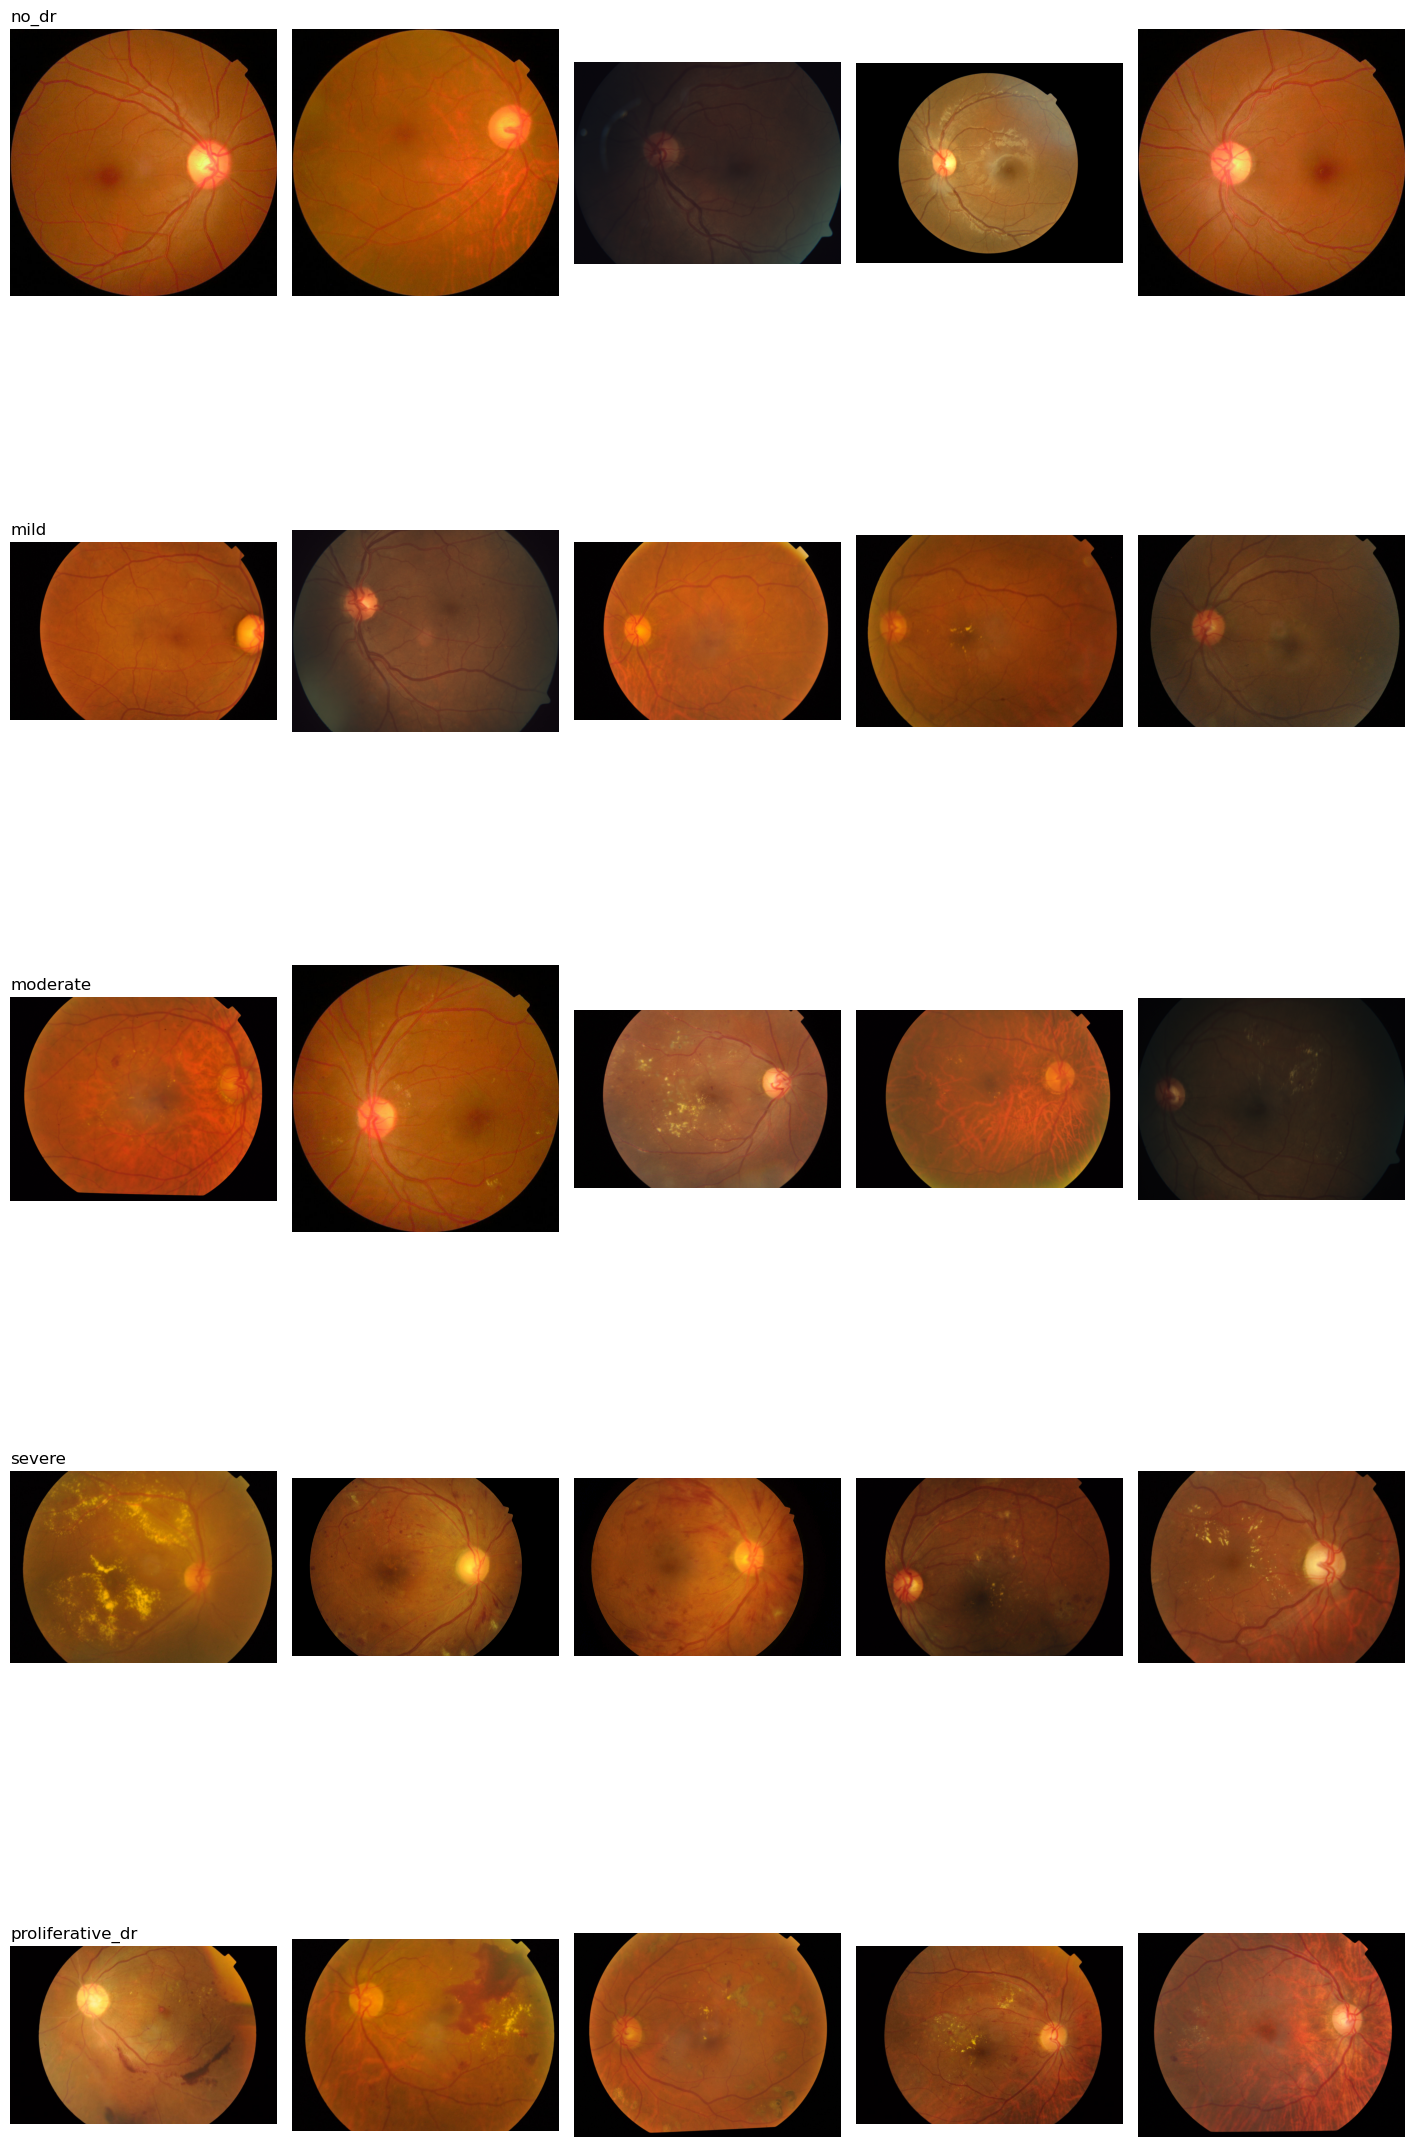

In [4]:
import random
from PIL import Image
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5 * len(classes)))

for i, cls in enumerate(classes):
    images = list((DATA_DIR / cls).glob("*"))
    selectedImages = random.sample(images, 5)

    for col, imagePath in enumerate(selectedImages):
        image = Image.open(imagePath)

        plt.subplot(len(classes), 5, i * 5 + col + 1)
        plt.imshow(image)
        plt.axis("off")

        if col == 0:
            plt.title(cls, fontsize=12, loc="left")

plt.tight_layout(rect=[0.05, 0, 1, 1])
plt.show()

In [5]:
from collections import Counter

sizes = Counter()

for cls in classes:

    for img_path in (DATA_DIR / cls).glob("*"):

        try:
            img = Image.open(img_path)
            sizes[img.size] += 1
        except:
            pass

print(sizes.most_common(20))

[((1050, 1050), 974), ((2416, 1736), 638), ((2588, 1958), 533), ((4288, 2848), 512), ((3216, 2136), 410), ((2048, 1536), 351), ((819, 614), 287), ((3388, 2588), 141), ((1504, 1000), 92), ((1844, 1226), 61), ((640, 480), 42), ((2896, 1944), 34), ((2144, 1424), 28), ((1476, 1117), 14), ((474, 358), 2), ((1467, 1110), 2), ((2146, 1764), 1)]


In [6]:
modes=Counter()
for cls in classes:

    for imgPath in (DATA_DIR/cls).glob("*"):
        try:
            img=Image.open(imgPath)
            modes[img.mode]+=1

        except:
            pass

print(modes)

Counter({'RGB': 4122})


In [7]:
import numpy as np
means=[]
std=[]

for cls in classes:
    for imgPath in (DATA_DIR/cls).glob("*"):
        img=np.array(Image.open(imgPath).convert("RGB"))

        means.append(img.mean())
        std.append(img.std())

print('AVERAWGE picle intesntist',np.mean(means))
print('AVERAWGE picle std deviation',np.mean(std))

AVERAWGE picle intesntist 60.34340117942818
AVERAWGE picle std deviation 56.286358042219746


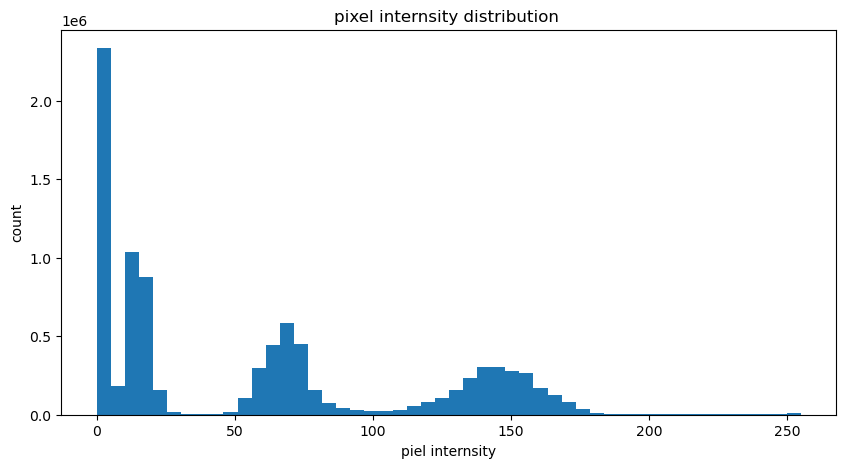

In [8]:
plt.figure(figsize=(10,5))
img=np.array(Image.open(random.choice(list((DATA_DIR/"moderate").glob("*")))).convert("RGB"))

plt.hist(img.ravel(),bins=50)
plt.xlabel("piel internsity")
plt.ylabel("count")
plt.title("pixel internsity distribution ")
plt.show()

In [11]:
import cv2
import numpy as np

def blur_score(image_path):

    img = cv2.imread(str(image_path))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    return cv2.Laplacian(gray, cv2.CV_64F).var()

In [13]:
scores = []

for cls in classes:

    for img_path in (DATA_DIR / cls).glob("*"):

        score = blur_score(img_path)

        scores.append({
            "class": cls,
            "image": img_path.name,
            "blur_score": score
        })

blur_df = pd.DataFrame(scores)

blur_df['blur_score'].mean

np.float64(23.747754809054374)

In [16]:
blur_df.head()

,class,image,blur_score
0,no_dr,aptos_002c21358ce6.png,42.167755
1,no_dr,aptos_005b95c28852.png,27.614819
2,no_dr,aptos_0097f532ac9f.png,12.599714
3,no_dr,aptos_00cc2b75cddd.png,38.565752
4,no_dr,aptos_00f6c1be5a33.png,45.413593
